# **📊 Movie Data Analysis**

-------------------------------------------------------

# **📖 Problem Statement**

The objective of this project is to analyze a movie dataset to uncover meaningful insights related to genre distribution, popularity, audience engagement, and release trends. By exploring key features such as ratings, vote counts, and genres, the analysis aims to identify patterns that influence movie success and audience preferences.

# **🎯 Objectives**

Identify the most frequent movie genres
Analyze rating categories and their audience engagement (vote counts)
Determine the most and least popular movies
Examine the relationship between popularity, genre, and ratings
Identify the year with the highest number of movie releases
Understand overall trends in movie production over time

# **📊 Dataset Overview**

The dataset contains information about movies collected from TMDB (The Movie Database) release on Netflix.

**Key details:
- Total Records: 9837
- Total Features: 9**

The dataset includes information such as **movie titles, release dates, popularity scores,
ratings, vote counts, language, and genres.**

# **📘 Data Dictionary**

**Column Description:**

- Release_Date → Date when the movie was released
- Title → Name of the movie
- Overview → Brief description of the movie
- Popularity → Popularity score of the movie
- Vote_Count → Total number of votes received
- Vote_Average → Average rating of the movie
- Original_Language → Original language of the movie
- Genre → Category of the movie (Action, Drama, etc.)
- Poster_Url → URL of the movie poster

In [70]:
# import liabraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# import dataset.
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [72]:
# check the shape of the dataset.
df.shape

(9827, 9)

In [73]:
# check the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [74]:
# check for nan values.
df.isna().sum()

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [75]:
# correct the datatype.
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtypes)

datetime64[ns]


In [76]:
# As we only need the year so we will extract only year.
df['Release_Date']= df['Release_Date'].dt.year
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Check for duplicates

In [77]:
# check for duplicate values.
df.duplicated().sum()
print(f'{df.duplicated().sum()} duplicate found.')

0 duplicate found.


In [78]:
df.describe()

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000,9827.000000
mean,2006.203623,40.326088,1392.805536,6.439534
std,15.685554,108.873998,2611.206907,1.129759
min,1902.000000,13.354000,0.000000,0.000000
25%,2000.000000,16.128500,146.000000,5.900000
50%,2011.000000,21.199000,444.000000,6.500000
75%,2017.000000,35.191500,1376.000000,7.100000
max,2024.000000,5083.954000,31077.000000,10.000000


**Dropping the columns**

In [79]:
# Drop unnecessary columns.
df.drop(columns=['Overview','Original_Language','Poster_Url'],axis =1, inplace = True)

In [80]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

**Categorize  'Vote_Average' column :-**

We would cut the 'Vote_Average' column values and make 4 categories ['Popular','Average','Below_Average','Not_Popular']


In [81]:
"""
As we can see that 'vote_Average' column has many values so we will categorize them into labels.
"""
df['Vote_Average'].unique()

array([ 8.3,  8.1,  6.3,  7.7,  7. ,  6.6,  6.8,  5.3,  7.2,  5.9,  7.3,
        7.1,  5.1,  4.6,  6. ,  8.2,  5.4,  6.1,  8.4,  6.9,  5.8,  7.4,
        7.8,  8. ,  6.2,  6.7,  7.6,  8.6,  4.8,  5.5,  7.9,  6.4,  7.5,
        5.7,  2.2,  6.5,  0. ,  5.6,  5.2,  5. ,  8.5,  3.5,  4. ,  3.3,
        4.7,  4.2,  4.3,  2. ,  4.1,  4.9,  8.7,  4.5,  9.1,  4.4,  3.6,
        2.8,  3.9,  3.8,  9. ,  3. ,  3.1,  3.7,  3.4,  8.9,  2.9,  8.8,
        3.2,  1.5,  9.2,  2.5,  1.8,  2.4,  2.6, 10. ])

In [82]:

# Define bins and labels
bins = [0, 4, 6, 8, 10]
labels = ['Not_Popular', 'Below_Average', 'Average', 'Popular']

# Create new column
df['Rating_Category'] = pd.cut(df['Vote_Average'], bins=bins, labels=labels, include_lowest=True)

In [83]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Rating_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",Popular
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",Popular
2,2022,No Exit,2618.087,122,6.3,Thriller,Average
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",Average
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",Average


In [84]:
df['Rating_Category'].value_counts()

,count
Rating_Category,
Average,6603
Below_Average,2705
Popular,314
Not_Popular,205


In [85]:
# we don't need 'Value_Average' column we can drop it.
df.drop(columns=['Vote_Average'],axis =1, inplace = True)

**Split the 'Genre' into a list.**

In [86]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [87]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)

In [88]:
df['Genre'].value_counts()

,count
Genre,
Drama,3744
Comedy,3031
Action,2686
Thriller,2488
Adventure,1853
Romance,1476
Horror,1470
Animation,1439
Family,1414


In [89]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Genre,Rating_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,Action,Popular
1,2021,Spider-Man: No Way Home,5083.954,8940,Adventure,Popular
2,2021,Spider-Man: No Way Home,5083.954,8940,Science Fiction,Popular
3,2022,The Batman,3827.658,1151,Crime,Popular
4,2022,The Batman,3827.658,1151,Mystery,Popular


In [90]:
# casting column into category.

df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

# **Data Visualization**

**What is the most frequent genre of movies released on Netflix?**

In [91]:
df['Genre'].value_counts()

,count
Genre,
Drama,3744
Comedy,3031
Action,2686
Thriller,2488
Adventure,1853
Romance,1476
Horror,1470
Animation,1439
Family,1414


/tmp/ipykernel_14847/2060108098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index,palette="viridis")


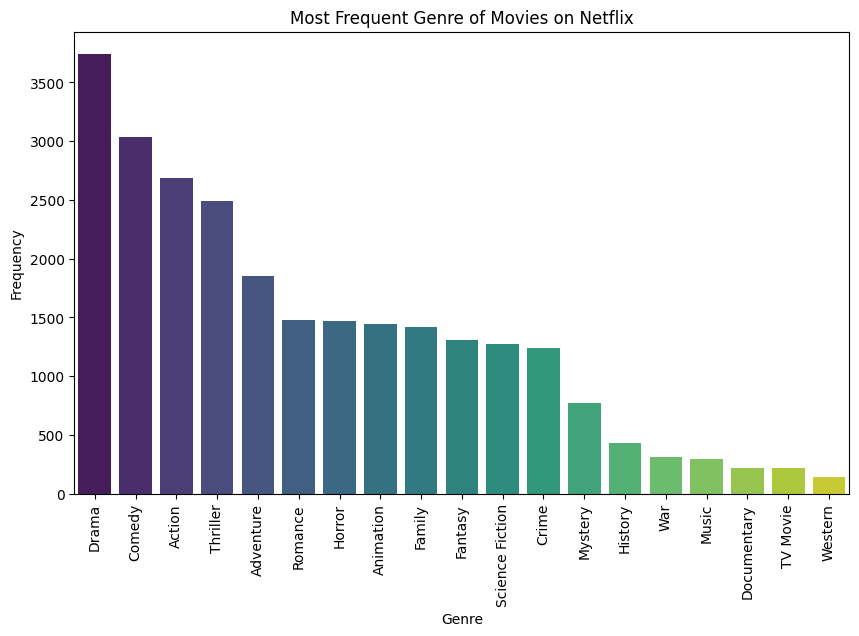

In [92]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index,palette="viridis")
plt.xticks(rotation=90)
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.title('Most Frequent Genre of Movies on Netflix')
plt.show()

**Which category has highest votes in Rating_Category column?**

In [93]:
highest_votes_genre = df.groupby('Rating_Category')['Vote_Count'].sum().reset_index()
highest_votes_genre

/tmp/ipykernel_14847/9014892.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  highest_votes_genre = df.groupby('Rating_Category')['Vote_Count'].sum().reset_index()


,Rating_Category,Vote_Count
0,Not_Popular,37568
1,Below_Average,5078124
2,Average,30240983
3,Popular,3457264


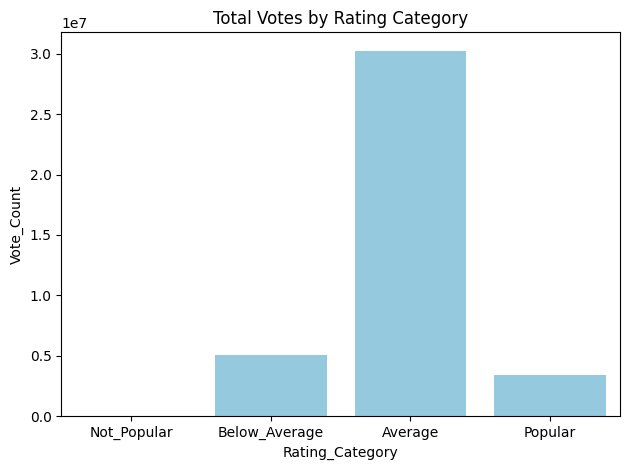

In [94]:
plt.figure()
sns.barplot(data=highest_votes_genre, x='Rating_Category', y='Vote_Count',color='skyblue')

plt.title("Total Votes by Rating Category")
plt.tight_layout()
plt.show()

**Which movie got the highest popularity? what's its genre?**

In [95]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Genre,Rating_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,Action,Popular
1,2021,Spider-Man: No Way Home,5083.954,8940,Adventure,Popular
2,2021,Spider-Man: No Way Home,5083.954,8940,Science Fiction,Popular


**Which movie got the lowest popularity? what's its genre?**



In [96]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Genre,Rating_Category
25787,2021,The United States vs. Billie Holiday,13.354,152,Music,Average
25788,2021,The United States vs. Billie Holiday,13.354,152,Drama,Average
25789,2021,The United States vs. Billie Holiday,13.354,152,History,Average
25790,1984,Threads,13.354,186,War,Average
25791,1984,Threads,13.354,186,Drama,Average
25792,1984,Threads,13.354,186,Science Fiction,Average


**Which year has the most filmmed movies?**

In [97]:
df['Release_Date'].value_counts()

,count
Release_Date,
2021,1638
2018,1387
2017,1365
2019,1272
2016,1212
...,...
1920,4
1902,3
1925,2


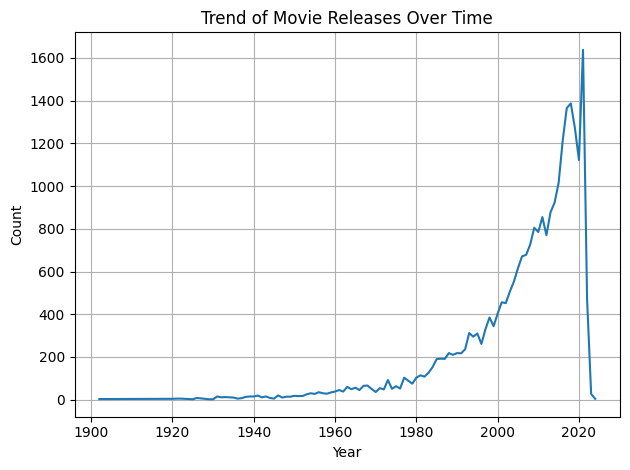

In [98]:
# Count movies per year
year_counts = df['Release_Date'].value_counts().sort_index()

sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Trend of Movie Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Count")

plt.grid(True)
plt.tight_layout()
plt.show()

- **Conclusion**

Based on the analysis of the movie dataset, the following key insights were derived:

1. **Most Frequent Genre Released on Netflix**

The most frequently occurring genre is **Drama**, with a total count of **3,744**, followed by **Comedy** with **3,031** entries. This indicates that drama-based content dominates the dataset.

2. **Rating Category with Highest Votes**
The **Average** rating category has received the highest total number of votes, with approximately **3,02,40,983 votes**, indicating strong audience engagement in moderately rated movies.

3. **Movie with Highest Popularity**

The movie Spider-Man: No Way Home has the highest popularity score of 5083.954.

- Genre: Action, Adventure, Science Fiction

- Vote Count: 8,940
- Rating Category: Popular
- Release Year: 2021

This shows that high-budget, action-oriented films tend to attract significant audience attention.

4. **Movies with Lowest Popularity:-**

Two movies were identified with the lowest popularity scores:

- **The United States vs. Billie Holiday (2021)**

- Popularity: 13.354

- Vote Count: 152

- Genre: Music, Drama, History

- Rating Category: Average

- **The Threads (1984)**

- Popularity: 13.354

- vote count : 186

- Genre: Drama, war, science friction

These movies received relatively low audience attention compared to others in the dataset.

5. **Year with Highest Number of Movie Releases:-**

The year 2021 recorded the highest number of movie releases, with a total of 1,638 movies, indicating a peak in production during this period.

**Final Insight**

Overall, the analysis reveals that Drama is the most dominant genre, Average-rated movies receive the highest engagement, and recent years (especially 2020–2021) show a significant increase in movie production and popularity trends.